# <u>Hornsund Fjord ice Types: Time Series Analysis (2012-2023) </u>  <br /> <sub> <span style="font-size:smaller;"> Jullian C.B. Williams </span> </sub> <br /> <sub> <span style="font-size:smaller;"> *Polish Academy of Sciences, Institute of Geophysics, Warsaw, Poland* </span> </sub>


###### This notebook plots the multi-classed ice types in the Hornsund Fjord, its adjacent bays and segment of the Greenland Sea. This shows the outputs from 2012 t0 2023 and takes a look into the correlation relationships between these areas which can suggest where the materials in the fjord are being generated and circulated to and from. 
###### This is the continuation of the previous notebook that displayed 2012 only from the SVM and Gaussian binary maps results.

##### ❄ ❄ ❄ ❄ ❄ ❄ ❄  &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;<span style="color:darkorange">Let's get started</span>&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;❄ ❄ ❄ ❄ ❄ ❄ ❄  

In [43]:
import emoji #<---- Death and taxes are for certain. Try to have fun before you're 6 feet too far under to.
from rich import print as printmoji
from rich.console import Console #<---- Ditto.

import fiona
import random
import warnings
import argparse, os
import pyarrow as pa
from datetime import datetime
from shapely.geometry import box
from shapely.geometry import shape
from shapely.geometry import Polygon
from shapely.affinity import translate

import numpy as np
import pandas as pd
from osgeo import ogr
from osgeo import gdal #<---- to geospatial env.
import geopandas as gpd

from PIL import Image

import seaborn as sns
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.plot import show_hist 
from rasterstats import zonal_stats
from rasterio.features import shapes
from rasterio.plot import adjust_band
from rasterio.features import rasterize

import seaborn as sns
import matplotlib.image
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import patches as mpatches
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from spectral import *
from sklearn import svm
from scipy import stats
from scipy import ndimage
from scipy import fftpack
from sklearn.svm import SVC
from scipy.fft import fft, ifft
from scipy.ndimage import zoom
from scipy.ndimage import sobel
from scipy.stats import entropy
import spectral.io.envi as envi #run PCA
from sklearn.svm import LinearSVC
from skimage import io, transform # from scipy.misc import imresize  <---- here...we...go..
from scipy.stats import normaltest
from skimage.morphology import disk #manage disk while running.
from skimage.segmentation import slic
from sklearn.decomposition import PCA
from skimage.util import img_as_ubyte #Avoid precision loss converting image of type float32 to uint8 as required by rank filters.
from skimage.filters.rank import entropy #for GLCM entropy.
from sklearn.pipeline import make_pipeline
from skimage.segmentation import chan_vese
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from skimage.feature import graycomatrix, graycoprops # from skimage.feature import greycomatrix, greycoprops <--- depreciated or..? lang.
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

## Multi-classed Fjord

In [3]:
input_dir = input_dir = "C:/Users/HP/Desktop/HORNSUND/ALL_SAT/composite/12_23_seasons_clip/rs2_clip/summer/"

dataframesrss = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 17
                        bfposition = 9
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframesrss.append(gdf)

In [5]:
input_dir = input_dir = "C:/Users/HP/Desktop/HORNSUND/ALL_SAT/composite/12_23_seasons_clip/s1_clip/summer/"

dataframes1s = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframes1s.append(gdf)

In [6]:
input_dir = input_dir = "C:/Users/HP/Desktop/HORNSUND/ALL_SAT/composite/12_23_seasons_clip/rs2_clip/winter/"

dataframesrsw = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 17
                        bfposition = 9
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframesrsw.append(gdf)

In [7]:
input_dir = input_dir = "C:/Users/HP/Desktop/HORNSUND/ALL_SAT/composite/12_23_seasons_clip/s1_clip/winter/"

dataframes1w = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframes1w.append(gdf)

In [8]:
rssummer = pd.concat(dataframesrss, ignore_index=True)
s1summer = pd.concat(dataframes1s, ignore_index=True)
rswinter = pd.concat(dataframesrsw, ignore_index=True)
s1winter = pd.concat(dataframes1w, ignore_index=True)
summer = pd.concat([rssummer,s1summer], ignore_index=True)
winter = pd.concat([rswinter,s1winter], ignore_index=True)
# print(rswinter)

In [9]:
rsmulti = pd.concat([summer,winter], ignore_index=True)
print(rsmulti)

         value                                           geometry       date  \
0         10.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1         10.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2         10.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3         10.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4         10.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...        ...                                                ...        ...   
7748813    0.0  POLYGON ((542975 8552725, 542975 8552675, 5429... 2023-04-30   
7748814   10.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
7748815    1.0  POLYGON ((513675 8531175, 513675 8531125, 5136... 2023-04-30   
7748816    0.0  POLYGON ((513925 8531025, 513925 8530975, 5140... 2023-04-30   
7748817   10.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

                area  perimeter        

In [11]:
rsw = rsmulti.drop(rsmulti[rsmulti['area'] >= 2e7].index) # Remove wrapper cells
print(rsw)

         value                                           geometry       date  \
0         10.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1         10.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2         10.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3         10.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4         10.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...        ...                                                ...        ...   
7748812    1.0  POLYGON ((513925 8531125, 513925 8531025, 5140... 2023-04-30   
7748814   10.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
7748815    1.0  POLYGON ((513675 8531175, 513675 8531125, 5136... 2023-04-30   
7748816    0.0  POLYGON ((513925 8531025, 513925 8530975, 5140... 2023-04-30   
7748817   10.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

             area  perimeter           

C:\Users\HP\anaconda3\envs\notebook\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


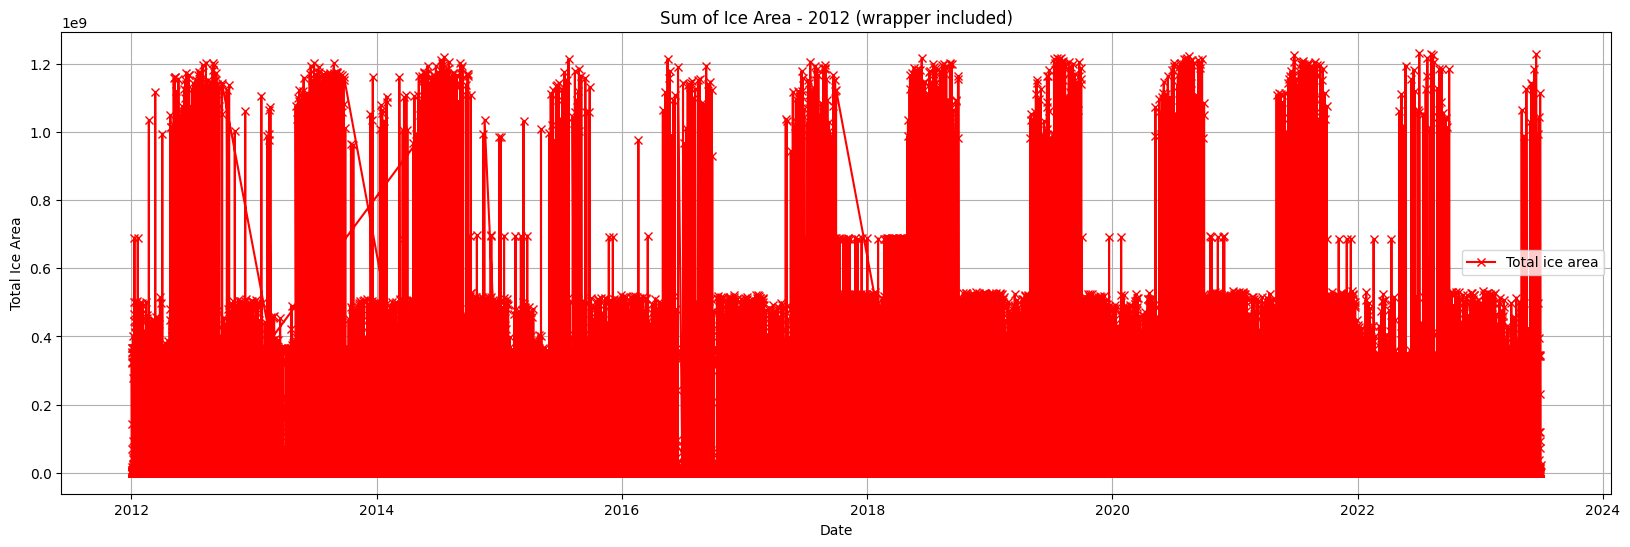

In [12]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(rsmulti['date'], rsmulti['area'], c= 'red', marker='x', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
plt.title('Sum of Ice Area - 2012 (wrapper included)')
plt.legend()
plt.grid()
plt.show()

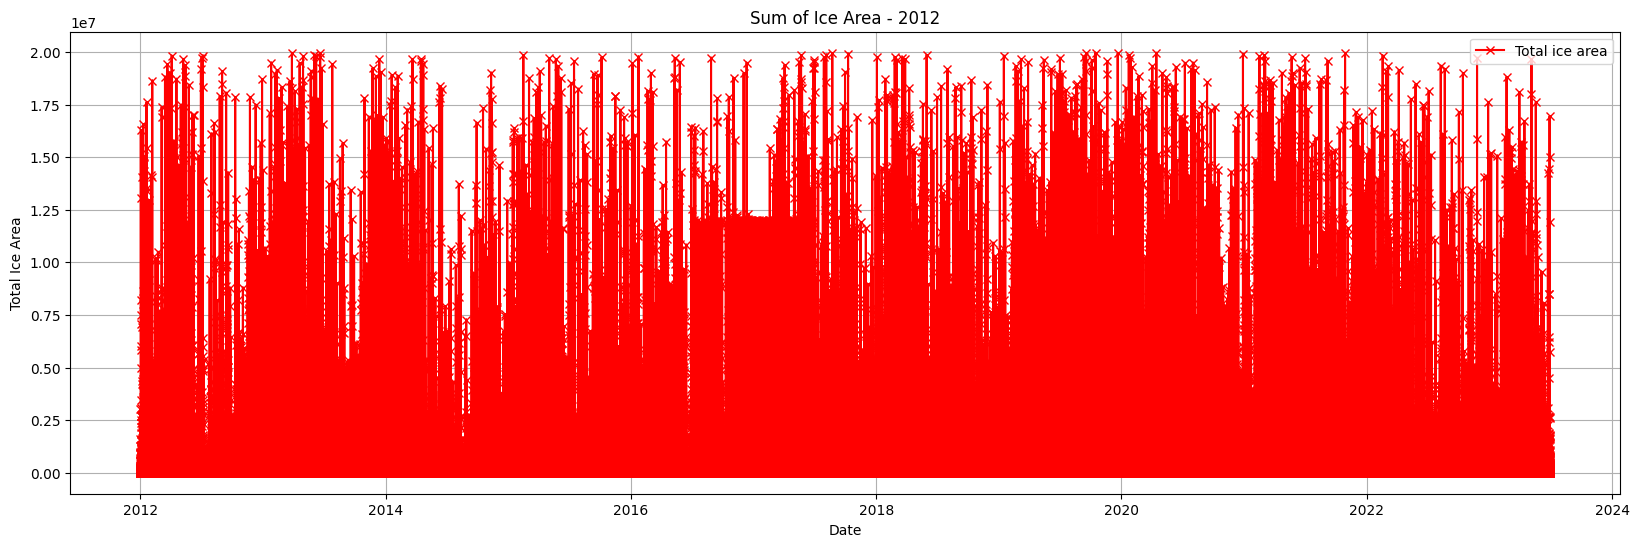

In [13]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(rsw['date'], rsw['area'], c= 'red', marker='x', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
plt.title('Sum of Ice Area - 2012')
plt.legend()
plt.grid()
plt.show()

In [16]:
result = rsw.groupby(['date', 'value'])['area'].sum().reset_index()
print(result)

            date  value        area
0     2012-01-02    0.0  13162500.0
1     2012-01-02    1.0   4967500.0
2     2012-01-02    2.0    607500.0
3     2012-01-02    4.0    217500.0
4     2012-01-02    6.0   1852500.0
...          ...    ...         ...
22331 2023-06-29    4.0   2197500.0
22332 2023-06-29    5.0     62500.0
22333 2023-06-29    6.0  20977500.0
22334 2023-06-29    7.0    280000.0
22335 2023-06-29   10.0  13040000.0

[22336 rows x 3 columns]


In [48]:
df = pd.DataFrame(rsw)

# Function to assign labels based on value
def ice_type(value):
    if pd.isna(value):  # Handle missing values
        return 'Unknown'
    elif value == 1:
        return 'GLS Drift'
    elif value == 2:
        return 'BrepollenFST'
    elif value == 3:
        return 'BrepollenGCR'
    elif value == 4:
        return 'SamarinvagenFST'
    elif value == 5:
        return 'SamarinvagenGCR'
    elif value == 6:
        return 'BurgerbuktaFST'
    elif value == 7:
        return 'BurgerbuktaGCR'
    elif value == 8:
        return 'IsbjornhamnaFST'
    elif value == 9:
        return 'IsbjornhamnaGCR'
    elif value == 10:
        return 'Hornsund DFT'
    else:
        return 'clip'

# Create new column 'label' using apply
df['type'] = df['value'].apply(ice_type)

print(df)

         value                                           geometry       date  \
0         10.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1         10.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2         10.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3         10.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4         10.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...        ...                                                ...        ...   
7748812    1.0  POLYGON ((513925 8531125, 513925 8531025, 5140... 2023-04-30   
7748814   10.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
7748815    1.0  POLYGON ((513675 8531175, 513675 8531125, 5136... 2023-04-30   
7748816    0.0  POLYGON ((513925 8531025, 513925 8530975, 5140... 2023-04-30   
7748817   10.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

             area  perimeter           

In [49]:
df = df.drop(df[df['type'] == 'clip'].index) # For some reason, the clipping works on and off.. go figure.
print(df)

         value                                           geometry       date  \
0         10.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1         10.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2         10.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3         10.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4         10.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...        ...                                                ...        ...   
7748811    1.0  POLYGON ((514975 8531425, 514975 8531325, 5149... 2023-04-30   
7748812    1.0  POLYGON ((513925 8531125, 513925 8531025, 5140... 2023-04-30   
7748814   10.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
7748815    1.0  POLYGON ((513675 8531175, 513675 8531125, 5136... 2023-04-30   
7748817   10.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

             area  perimeter           

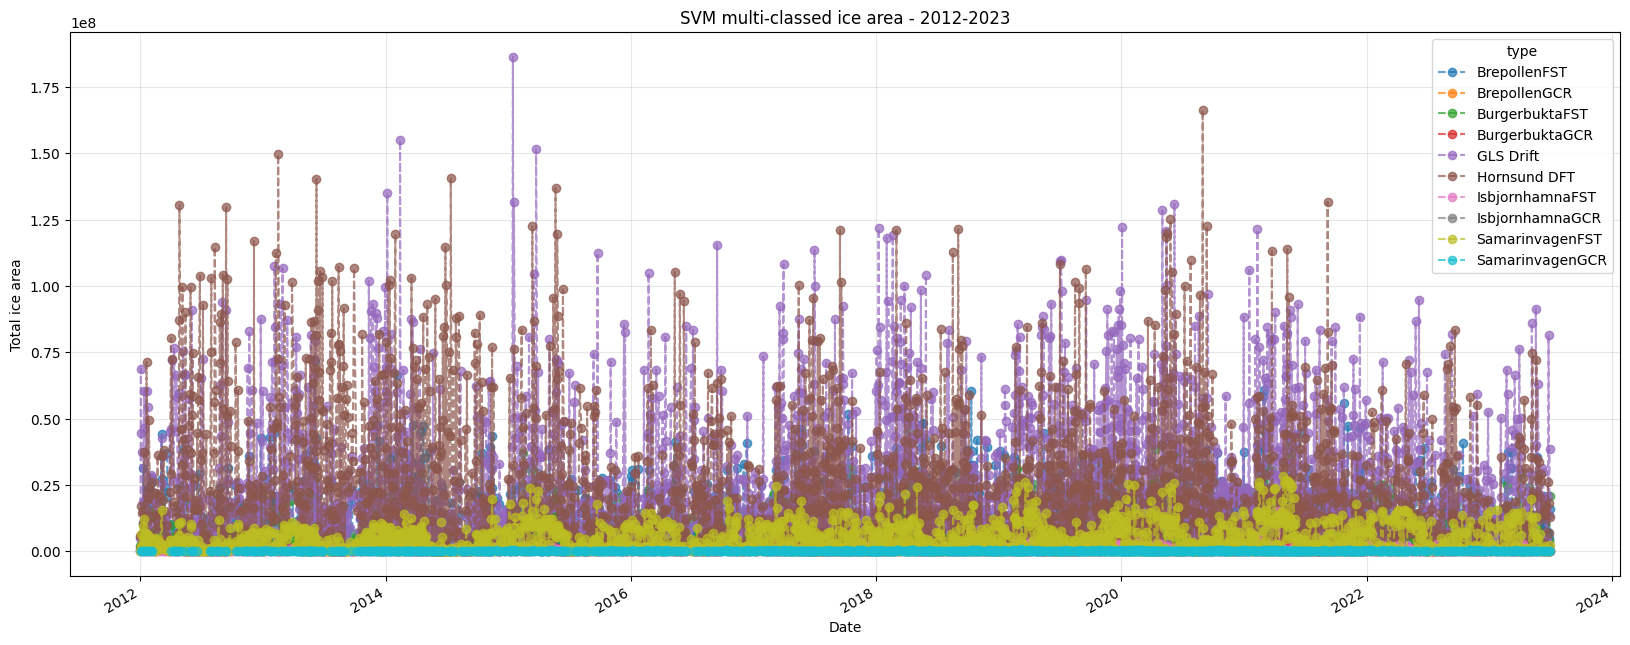

In [25]:
df.groupby([df["date"],"type"])["area"].sum().unstack().plot(figsize=(20, 8),marker='o', linestyle='--', alpha = 0.7)
plt.ylabel('Total ice area')
plt.xlabel('Date')
plt.title('SVM multi-classed ice area - 2012-2023')
loc='best'
plt.grid(alpha=0.3)
# plt.savefig("C:/Users/jullian.williams/Desktop/HIRLOMAP/frnd/ALL_SAT/composite/RS2/Multi_plot/multi_class12.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

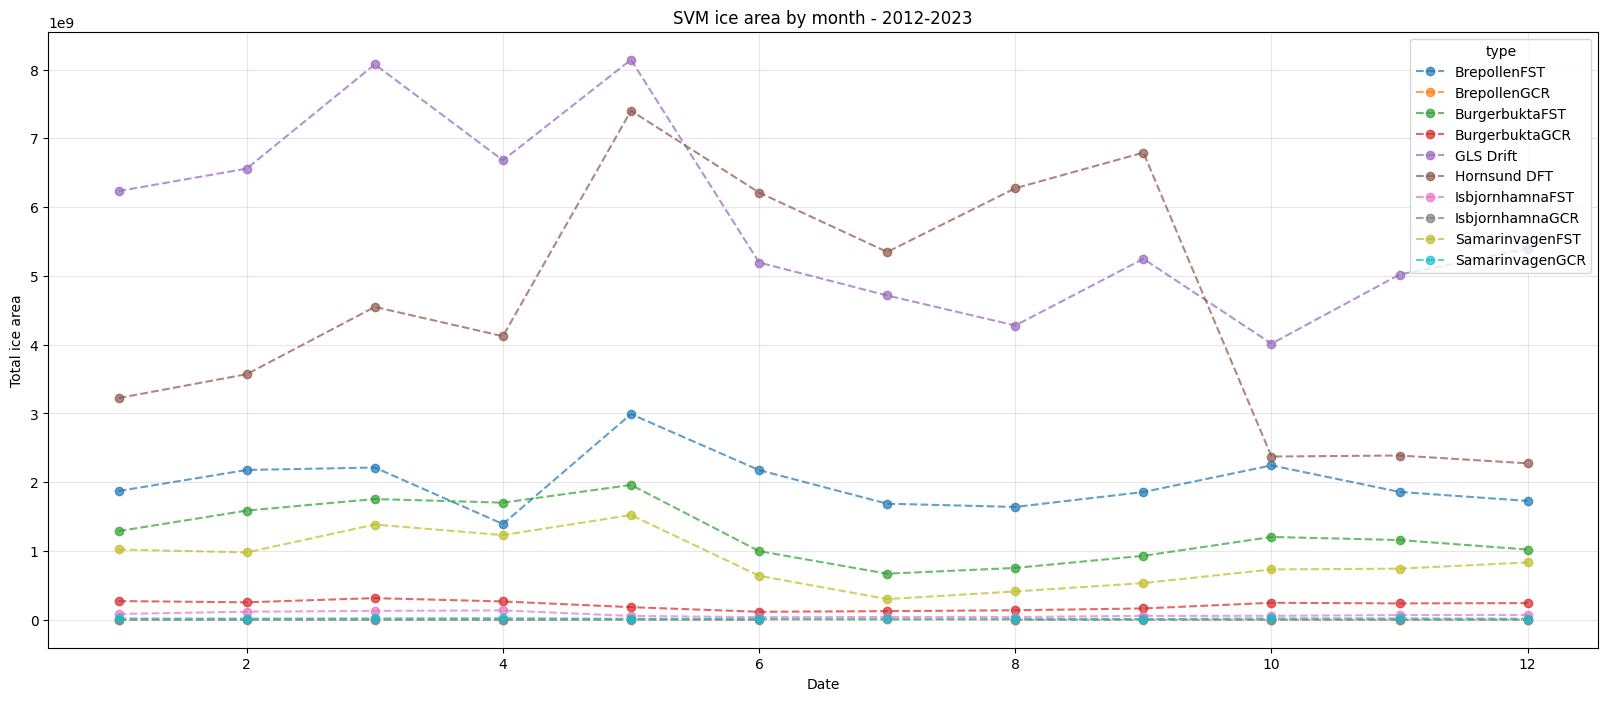

In [26]:
df.groupby([df["date"].dt.month,"type"])["area"].sum().unstack().plot(figsize=(20, 8),marker='o', linestyle='--', alpha = 0.7)
plt.ylabel('Total ice area')
plt.xlabel('Date')
plt.title('SVM ice area by month - 2012-2023')
loc='best'
plt.grid(alpha=0.3)
# plt.savefig("C:/Users/jullian.williams/Desktop/HIRLOMAP/frnd/ALL_SAT/composite/RS2/Multi_plot/multi_bymnth.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

## Correlations between the bays, main basin and Greenland Sea

In [50]:
mty = (df.groupby([df['date'].dt.month,'type']))['area'].mean().unstack()
mty

type,BrepollenFST,BrepollenGCR,BurgerbuktaFST,BurgerbuktaGCR,GLS Drift,Hornsund DFT,IsbjornhamnaFST,IsbjornhamnaGCR,SamarinvagenFST,SamarinvagenGCR
date,,,,,,,,,,
1,356707.642462,64090.909091,7.252167e+05,120902.808738,78465.746009,105906.245893,253893.939394,85000.000000,7.806780e+05,98625.654450
2,406284.514925,88139.534884,1.006281e+06,115100.045475,88689.917659,124121.818940,298054.846939,75000.000000,7.991605e+05,92622.282609
3,420939.520730,75394.736842,1.056143e+06,122634.607881,94153.326415,136745.881433,301229.411765,75000.000000,1.090871e+06,89054.054054
4,341239.887227,64934.210526,1.343552e+06,120451.451906,91594.984782,128760.969364,370924.657534,50000.000000,1.111612e+06,90722.656250
5,380852.866242,65723.684211,1.061152e+06,87192.564347,61983.277006,71183.667680,180163.398693,80000.000000,1.222159e+06,71528.571429
6,337758.500233,61168.831169,7.562509e+05,83210.678211,58788.310924,64517.948398,174870.283019,55000.000000,6.211381e+05,76268.656716
7,280070.136122,67243.589744,5.628280e+05,83091.666667,55027.690566,65218.735517,161956.967213,NaN,3.596467e+05,65046.296296
8,279362.436116,60265.957447,5.447072e+05,84321.384804,50872.632255,63467.757435,150610.687023,50000.000000,3.667328e+05,71338.028169
9,259785.634354,63470.149254,5.267673e+05,86272.344900,53851.669608,63460.623926,188513.513514,54166.666667,4.002385e+05,68758.278146


In [51]:
cormty = mty.corr()
cormty

type,BrepollenFST,BrepollenGCR,BurgerbuktaFST,BurgerbuktaGCR,GLS Drift,Hornsund DFT,IsbjornhamnaFST,IsbjornhamnaGCR,SamarinvagenFST,SamarinvagenGCR
type,,,,,,,,,,
BrepollenFST,1.000000,0.635497,0.550422,0.704554,0.587333,0.660234,0.387950,0.472903,0.630732,0.688361
BrepollenGCR,0.635497,1.000000,0.324508,0.524688,0.584840,0.625630,0.436961,0.425160,0.253205,0.446624
BurgerbuktaFST,0.550422,0.324508,1.000000,0.476654,0.763473,0.709677,0.789903,0.079588,0.901073,0.276525
BurgerbuktaGCR,0.704554,0.524688,0.476654,1.000000,0.799458,0.895288,0.725760,0.379686,0.475890,0.883344
GLS Drift,0.587333,0.584840,0.763473,0.799458,1.000000,0.968340,0.947215,0.392712,0.708158,0.589414
Hornsund DFT,0.660234,0.625630,0.709677,0.895288,0.968340,1.000000,0.910038,0.317962,0.634049,0.684438
IsbjornhamnaFST,0.387950,0.436961,0.789903,0.725760,0.947215,0.910038,1.000000,0.158620,0.656151,0.476364
IsbjornhamnaGCR,0.472903,0.425160,0.079588,0.379686,0.392712,0.317962,0.158620,1.000000,0.418584,0.397396
SamarinvagenFST,0.630732,0.253205,0.901073,0.475890,0.708158,0.634049,0.656151,0.418584,1.000000,0.294191


In [52]:
yty = (df.groupby([df['date'].dt.year,'type']))['area'].mean().unstack()
yty

type,BrepollenFST,BrepollenGCR,BurgerbuktaFST,BurgerbuktaGCR,GLS Drift,Hornsund DFT,IsbjornhamnaFST,IsbjornhamnaGCR,SamarinvagenFST,SamarinvagenGCR
date,,,,,,,,,,
2012,284719.769328,61818.181818,5.338520e+05,83952.576550,56028.076496,68414.519658,166228.991597,60000.000000,5.049096e+05,71594.827586
2013,285216.151306,61166.666667,6.373242e+05,86839.213418,61543.586657,72025.127375,220059.288538,60000.000000,5.550609e+05,72908.653846
2014,358156.666667,68645.833333,5.063169e+05,87081.939799,53636.779453,62654.143030,204381.188119,107500.000000,5.137864e+05,66724.806202
2015,325515.923567,68679.245283,1.019245e+06,104206.325301,74951.347591,100602.670898,236462.450593,NaN,1.019485e+06,82108.843537
2016,367101.949190,67016.129032,7.324452e+05,110168.860904,63871.216165,83739.179246,196524.390244,55000.000000,7.226348e+05,89020.000000
2017,353698.327759,67000.000000,8.918699e+05,109033.009709,64129.410180,77312.956864,212645.502646,64166.666667,7.398346e+05,89099.576271
2018,407990.607514,69920.634921,7.555432e+05,115024.608093,72930.763660,86939.139653,247276.029056,80625.000000,6.593322e+05,96075.697211
2019,351089.383607,65979.729730,7.118742e+05,113692.030230,79019.430312,88504.938994,270867.346939,67000.000000,7.354997e+05,89595.864662
2020,299160.779881,62401.315789,9.976381e+05,113603.580991,72251.124151,85036.284520,263808.724832,51666.666667,7.028745e+05,89679.487179


In [53]:
coryty = yty.corr()
coryty

type,BrepollenFST,BrepollenGCR,BurgerbuktaFST,BurgerbuktaGCR,GLS Drift,Hornsund DFT,IsbjornhamnaFST,IsbjornhamnaGCR,SamarinvagenFST,SamarinvagenGCR
type,,,,,,,,,,
BrepollenFST,1.000000,0.816040,0.415664,0.613120,0.473950,0.253157,0.272625,0.291576,0.531445,0.531455
BrepollenGCR,0.816040,1.000000,0.296149,0.487875,0.382882,0.221686,0.096337,0.195116,0.483393,0.228501
BurgerbuktaFST,0.415664,0.296149,1.000000,0.630895,0.758011,0.646530,0.546570,-0.582183,0.923273,0.608993
BurgerbuktaGCR,0.613120,0.487875,0.630895,1.000000,0.818801,0.649243,0.599337,-0.324514,0.583292,0.839955
GLS Drift,0.473950,0.382882,0.758011,0.818801,1.000000,0.797188,0.777289,-0.391243,0.779109,0.711898
Hornsund DFT,0.253157,0.221686,0.646530,0.649243,0.797188,1.000000,0.664643,-0.475561,0.677407,0.723760
IsbjornhamnaFST,0.272625,0.096337,0.546570,0.599337,0.777289,0.664643,1.000000,-0.069903,0.450232,0.655071
IsbjornhamnaGCR,0.291576,0.195116,-0.582183,-0.324514,-0.391243,-0.475561,-0.069903,1.000000,-0.529765,-0.369473
SamarinvagenFST,0.531445,0.483393,0.923273,0.583292,0.779109,0.677407,0.450232,-0.529765,1.000000,0.504373


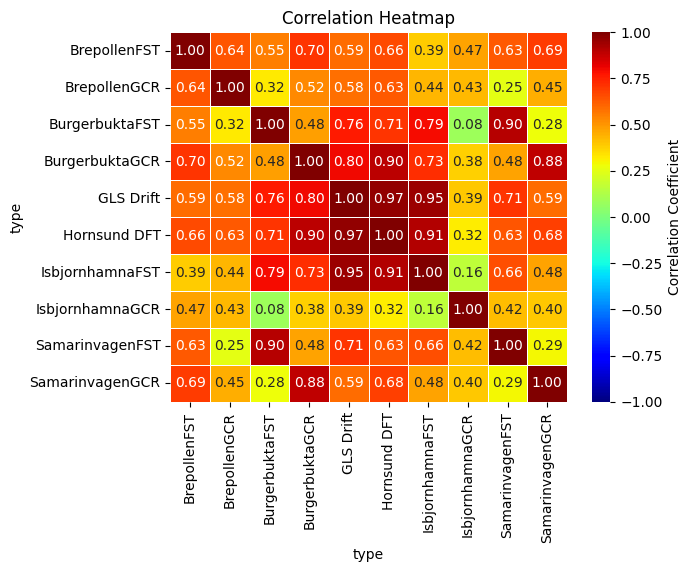

In [54]:
sns.heatmap(
    cormty, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
# plt.savefig("C:/Users/jullian.williams/Desktop/HIRLOMAP/frnd/ALL_SAT/composite/RS2/Multi_plot/multi_corr.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

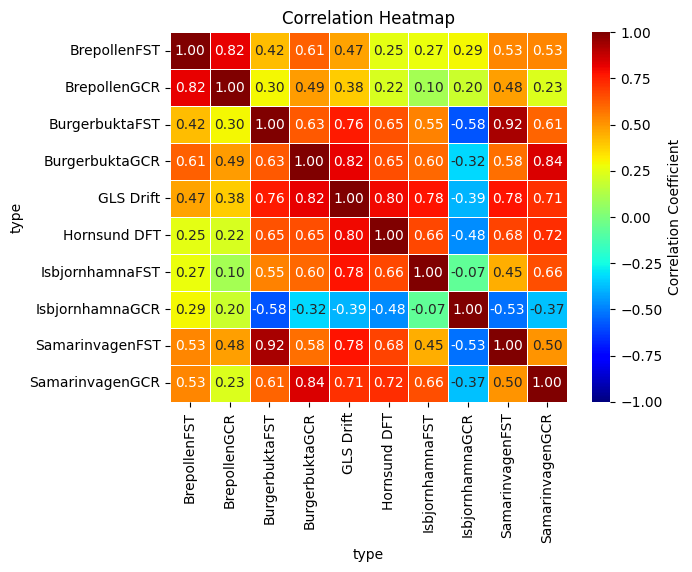

In [55]:
sns.heatmap(
    coryty, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
plt.show()